# Part 2: Compositionality Gap

Tests whether **SigLIP 2 So400m** can correctly compose information from two sub-tasks into a single joint answer, using real **AI2-THOR kitchen scenes** where both a Bowl and a Cup are visible simultaneously.

Caption-scoring approach (argmax over competing captions, no text generation):
- **Q1** bowl state: score `"a full bowl"` vs `"an empty bowl"` → argmax → predicted bowl state
- **Q2** cup state: score `"a full cup"` vs `"an empty cup"` → argmax → predicted cup state
- **Qp** joint state: score correct composite caption vs swapped composite → is the correct binding preferred?

**Compositionality gap** = cases where Q1=True AND Q2=True but Qp=False: the model identifies each object's state in isolation but fails to bind them correctly in the joint caption.

**Experiment 2** caption context effect: does adding relational context to Q1/Q2 captions hurt sub-question accuracy?

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pickle
import random
from pathlib import Path
from collections import defaultdict
from PIL import Image
from transformers import AutoProcessor, AutoModel

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc  = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()
print('SigLIP 2 So400m loaded')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 8455.47it/s]


SigLIP 2 So400m loaded


In [1]:
def score(image, texts):
    """Return SigLIP logit scores [n_texts] for one image."""
    if isinstance(texts, str):
        texts = [texts]
    inputs = proc(
        images=[image], text=texts,
        return_tensors='pt', padding='max_length', truncation=True
    ).to(device)
    with torch.no_grad():
        out = model(**inputs)
    return out.logits_per_image[0].cpu().float().numpy()  # [n_texts]

## 2. Load AI2-THOR scenes

Each scene: a 400×400 kitchen frame with both a Bowl and a Cup visible. States from simulation metadata.

Sub-question captions (argmax decides prediction):
- Q1: `"a full bowl"` vs `"an empty bowl"` → predicted bowl state
- Q2: `"a full cup"` vs `"an empty cup"` → predicted cup state

Compositional parent (scored as correct vs. swapped binding):
- Qp: `"a {bowl_state} bowl and a {cup_state} cup"` vs `"a {wrong_bowl} bowl and a {wrong_cup} cup"`

In [ ]:
random.seed(42)
DATA = Path('../data')

with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

random.shuffle(comp_scenes)

results = []
print(f'{"Scene":<18} {"bowl":>6} {"cup":>6} | {"Q1✓":>4} {"Q2✓":>4} {"Qp✓":>4} {"gap":>5}')
print('-' * 56)

for s in comp_scenes:
    b_true, c_true = s['bowl_state'], s['cup_state']
    b_wrong = 'empty' if b_true == 'full' else 'full'
    c_wrong = 'empty' if c_true == 'full' else 'full'

    correct_cap = f'a {b_true} bowl and a {c_true} cup'
    wrong_cap = f'a {b_wrong} bowl and a {c_wrong} cup'

    # Single forward pass for all 6 texts
    all_texts = ['a full bowl', 'an empty bowl',
                 'a full cup',  'an empty cup',
                 correct_cap,   wrong_cap]
    s_all = score(s['image'], all_texts)

    pred_bowl = 'full' if s_all[0] > s_all[1] else 'empty'
    pred_cup = 'full' if s_all[2] > s_all[3] else 'empty'
    qp_ok = s_all[4] > s_all[5]

    q1_ok = pred_bowl == b_true
    q2_ok = pred_cup  == c_true
    gap = q1_ok and q2_ok and not qp_ok

    results.append({
        'scene': s['scene'], 'bowl_state': b_true, 'cup_state': c_true,
        'same_state': s['same_state'],
        'q1_ok': q1_ok, 'q2_ok': q2_ok, 'qp_ok': qp_ok, 'gap': gap,
        'pred_bowl': pred_bowl, 'pred_cup': pred_cup,
    })
    sym = lambda b: '✅' if b else '❌' # Again using intentional emoji's for easy visualization
    print(f'{s["scene"]:<18} {b_true:>6} {c_true:>6} | '
          f'{sym(q1_ok):>4} {sym(q2_ok):>4} {sym(qp_ok):>4} {"← GAP" if gap else "":>5}')

n = len(results)
print(f'\nQ1 accuracy:  {sum(r["q1_ok"] for r in results)}/{n}')
print(f'Q2 accuracy:  {sum(r["q2_ok"] for r in results)}/{n}')
print(f'Qp accuracy:  {sum(r["qp_ok"] for r in results)}/{n}')
print(f'Gap cases (Q1=True Q2=True Qp=False): {sum(r["gap"] for r in results)}/{n}')

Scene                bowl    cup |  Q1✓  Q2✓  Qp✓   gap
--------------------------------------------------------
FloorPlan28         empty   full |    ✅    ❌    ❌      
FloorPlan6           full   full |    ❌    ❌    ❌      
FloorPlan28          full  empty |    ❌    ✅    ❌      
FloorPlan6           full  empty |    ❌    ✅    ❌      
FloorPlan28         empty  empty |    ✅    ✅    ✅      
FloorPlan28          full   full |    ❌    ❌    ❌      
FloorPlan6           full  empty |    ❌    ✅    ✅      
FloorPlan28          full  empty |    ❌    ✅    ✅      
FloorPlan6          empty   full |    ✅    ❌    ❌      
FloorPlan6          empty   full |    ✅    ❌    ✅      
FloorPlan6          empty  empty |    ✅    ✅    ✅      
FloorPlan28          full  empty |    ❌    ✅    ❌      
FloorPlan28          full   full |    ❌    ❌    ❌      
FloorPlan28         empty  empty |    ✅    ✅    ✅      
FloorPlan6          empty   full |    ✅    ❌    ✅      
FloorPlan28         empty   full |    ✅    ❌   

## 3. Caption context effect

Does adding relational context to Q1/Q2 captions change sub-question accuracy?

Three caption levels for Q1 (bowl state):
| Level | Caption |
|---|---|
| **Atomic** | `"a full bowl"` vs `"an empty bowl"` |
| **Contextual** | `"a full bowl next to a cup"` vs `"an empty bowl next to a cup"` |
| **Relational** | `"a full bowl and an empty cup"` vs `"an empty bowl and a full cup"` (composite, requires binding) |

If SigLIP is doing BoW, accuracy should be similar across levels. If adding the cup mention hurts, the model is attending to the wrong object.

In [6]:
ctx_results = []

print(f'{"Scene":<18} {"bowl":>6} {"cup":>6} | {"atomic":>7} {"context":>9} {"relat":>7}')
print('-' * 58)

for s in comp_scenes:
    b_true, c_true = s['bowl_state'], s['cup_state']
    b_wrong = 'empty' if b_true == 'full' else 'full'
    c_wrong = 'empty' if c_true == 'full' else 'full'

    # All captions in one forward pass
    texts = [
        'a full bowl', 'an empty bowl',                              # atomic [0,1]
        'a full bowl next to a cup', 'an empty bowl next to a cup',  # contextual [2,3]
        f'a {b_true} bowl and a {c_true} cup',                       # relational correct [4]
        f'a {b_wrong} bowl and a {c_wrong} cup',                     # relational wrong [5]
    ]
    s_all = score(s['image'], texts)

    ok_atom = (s_all[0] > s_all[1]) == (b_true == 'full')
    ok_ctx = (s_all[2] > s_all[3]) == (b_true == 'full')
    ok_rel = s_all[4] > s_all[5]

    sym = lambda b: '✅' if b else '❌'
    ctx_results.append({'scene': s['scene'], 'bowl_state': b_true, 'cup_state': c_true,
                        'atomic': ok_atom, 'contextual': ok_ctx, 'relational': ok_rel})
    print(f'{s["scene"]:<18} {b_true:>6} {c_true:>6} | '
          f'{sym(ok_atom):>7} {sym(ok_ctx):>9} {sym(ok_rel):>7}')

n = len(ctx_results)
print(f'\nAtomic accuracy:      {sum(r["atomic"] for r in ctx_results)}/{n}')
print(f'Contextual accuracy:  {sum(r["contextual"] for r in ctx_results)}/{n}')
print(f'Relational accuracy:  {sum(r["relational"] for r in ctx_results)}/{n}')

Scene                bowl    cup |  atomic   context   relat
----------------------------------------------------------
FloorPlan28         empty   full |       ✅         ❌       ❌
FloorPlan6           full   full |       ❌         ✅       ❌
FloorPlan28          full  empty |       ❌         ✅       ❌
FloorPlan6           full  empty |       ❌         ✅       ❌
FloorPlan28         empty  empty |       ✅         ❌       ✅
FloorPlan28          full   full |       ❌         ✅       ❌
FloorPlan6           full  empty |       ❌         ❌       ✅
FloorPlan28          full  empty |       ❌         ✅       ✅
FloorPlan6          empty   full |       ✅         ❌       ❌
FloorPlan6          empty   full |       ✅         ✅       ✅
FloorPlan6          empty  empty |       ✅         ✅       ✅
FloorPlan28          full  empty |       ❌         ✅       ❌
FloorPlan28          full   full |       ❌         ✅       ❌
FloorPlan28         empty  empty |       ✅         ✅       ✅
FloorPlan6          empty 

## 4. Results & interpretation

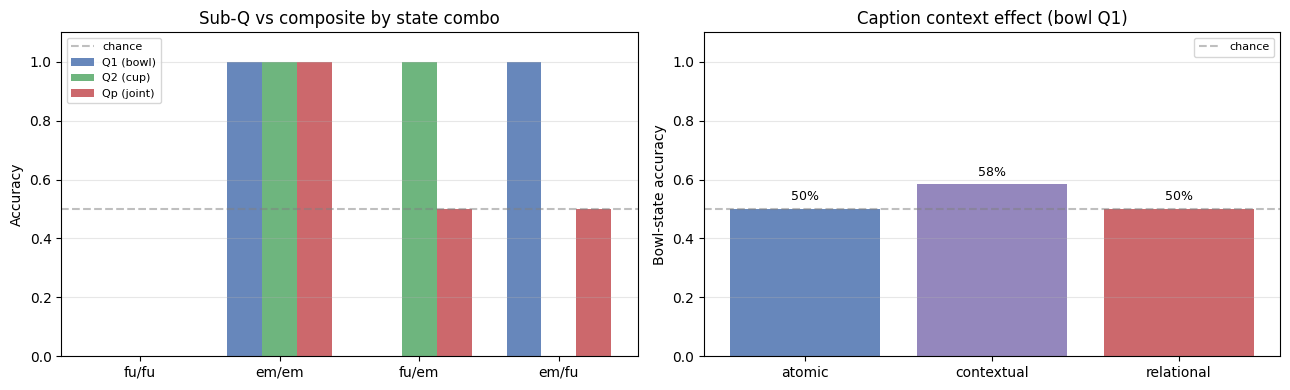

Gap cases (Q1=True Q2=True Qp=False): 0/24


In [8]:
import matplotlib.pyplot as plt

n = len(results)
gap_n = sum(r['gap'] for r in results)

# Accuracy by combo
combos = [('full','full'), ('empty','empty'), ('full','empty'), ('empty','full')]
combo_stats = {}
for b, c in combos:
    subset = [r for r in results if r['bowl_state']==b and r['cup_state']==c]
    if subset:
        combo_stats[f'{b[:2]}/{c[:2]}'] = {
            'Q1': sum(r['q1_ok'] for r in subset)/len(subset),
            'Q2': sum(r['q2_ok'] for r in subset)/len(subset),
            'Qp': sum(r['qp_ok'] for r in subset)/len(subset),
        }

# Bar chart: Q1 / Q2 / Qp accuracy per state combo
labels  = list(combo_stats.keys())
q1_vals = [combo_stats[l]['Q1'] for l in labels]
q2_vals = [combo_stats[l]['Q2'] for l in labels]
qp_vals = [combo_stats[l]['Qp'] for l in labels]

x = range(len(labels))
w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar([i-w for i in x], q1_vals, w, label='Q1 (bowl)', color='#4C72B0', alpha=0.85)
ax.bar([i   for i in x], q2_vals, w, label='Q2 (cup)',  color='#55A868', alpha=0.85)
ax.bar([i+w for i in x], qp_vals, w, label='Qp (joint)',color='#C44E52', alpha=0.85)
ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.set_title('Sub-Q vs composite by state combo')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Bar chart: caption context effect
ctx_n = len(ctx_results)
ctx_accs = [
    sum(r['atomic']      for r in ctx_results) / ctx_n,
    sum(r['contextual']  for r in ctx_results) / ctx_n,
    sum(r['relational']  for r in ctx_results) / ctx_n,
]
ax2 = axes[1]
bars = ax2.bar(['atomic','contextual','relational'], ctx_accs,
               color=['#4C72B0','#8172B2','#C44E52'], alpha=0.85)
for b, v in zip(bars, ctx_accs):
    ax2.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.0%}',
             ha='center', va='bottom', fontsize=9)
ax2.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax2.set_ylabel('Bowl-state accuracy'); ax2.set_ylim(0, 1.1)
ax2.set_title('Caption context effect (bowl Q1)')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Gap cases (Q1=True Q2=True Qp=False): {gap_n}/{n}')

## 5 · Results & Interpretation

| Experiment | Expected | Observed |
|---|---|---|
| Q1 bowl state (atomic) | Above chance | **50%** (12/24) empty-bias |
| Q2 cup state (atomic) | Above chance | **50%** (12/24) empty-bias |
| Qp joint composite | Lower than sub-Qs | **50%** (12/24) |
| Gap cases (Q1=True Q2=True Qp=False) | Some gap expected | **0/24** |
| Atomic vs contextual (bowl) | Similar | 50% → 58% (small gain) |
| Atomic vs relational (bowl) | Drop | 50% → 50% (unchanged) |

---

### The dominant failure: empty-object bias

Q1 and Q2 are each exactly 50% because SigLIP 2 consistently scores `"an empty X"` higher than `"a full X"` for both objects in isolation, regardless of the actual image content. The 50% accuracy is coincidental: exactly half the dataset has each state.

This is a **training-data prior**. In LAION-scale web data, isolated kitchenware images are predominantly product photos (empty containers). Descriptions like `"a full bowl"` appear in context-rich captions (`"a bowl of soup"`), while `"an empty bowl"` is a standalone description. SigLIP (presumably) learned empty as the default visual state for containers.

### Why the gap is 0/24

The compositionality gap requires Q1=True AND Q2=True simultaneously. Given the empty-bias:
- Q1 is correct only when `bowl=empty` (12 scenes)
- Q2 is correct only when `cup=empty` (12 scenes)
- Both correct only when `bowl=empty AND cup=empty` (6 scenes)

For all 6 `empty/empty` scenes, Qp is also correct, the correct composite `"an empty bowl and an empty cup"` beats the wrong `"a full bowl and a full cup"` because the empty-bias helps both halves. So every Q1=True AND Q2=True case is also Qp=True, leaving 0 gap cases by construction.

### Two priors operating at different levels

This experiment and the binding test reveal priors at different granularities:

| Level | Prior |
|---|---|
| **Atomic** (Q1/Q2 here) | `empty > full` for both objects individually |
| **Composite** (Winoground in binding_tests) | `full-bowl + empty-cup > empty-bowl + full-cup` |

These are not contradictory, they reflect different co-occurrence statistics in training data. Isolated kitchenware → empty. Kitchen scene with bowl + cup → bowl typically full (containing food), cup incidental.

### Caption context (Exp 2)

Adding `"next to a cup"` to the bowl caption marginally improved accuracy (50% → 58%), possibly because the more specific description better matches naturalistic training captions. Adding full relational binding (`"a full bowl and an empty cup"` vs swap) returned to 50%, consistent with the binding test Winoground result showing chance-level relational scoring on the full dataset.

### Implication

Neither the compositionality gap nor reliable sub-task accuracy can be demonstrated with SigLIP 2 zero-shot on fill-state captions. The model's priors dominate the signal. This is precisely the motivation for the supervised adapter: training directly on simulation ground-truth labels forces the model to overcome these distributional priors and use the actual visual content.